Project Overview

This project focuses on analyzing social media data to understand user engagement patterns and identify the factors that influence content performance. By applying exploratory data analysis (EDA) and basic statistical techniques, the project aims to extract meaningful insights from raw social media metrics such as views, likes, comments, and content duration.

In [ ]:
# Install required libraries for YouTube Data API and data analysis
%pip install google-api-python-client pandas
%pip install pandas numpy scipy matplotlib seaborn isodate

from googleapiclient.discovery import build

# Initialize YouTube API client with API key
api_key = ''
youtube = build('youtube', 'v3', developerKey=api_key)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Data Loading

In this section, the dataset is loaded using Python data analysis libraries. The goal is to import the data into a structured format that allows efficient inspection, cleaning, and analysis. After loading, the dataset structure is examined to understand the available features and their data types.

In [19]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sb
import isodate
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# Function to fetch channel statistics using YouTube Data API
def get_channel_stats(channel_id, channel_name,  max_videos=1000):
    # Fetch the channel details using the YouTube Data API
    res = youtube.channels().list(id=channel_id, part='contentDetails').execute()

    # Extract the items from the response
    items = res.get('items', [])
    if not items:
        # If no channel data is found, print a warning and return an empty list
        print(f"Warning: No channel data found for {channel_name} (ID: {channel_id})")
        return []

    # Get the ID of the uploads playlist for the channel
    playlist_id = items[0]['contentDetails']['relatedPlaylists']['uploads']
    
    # Initialize an empty list to store video IDs
    video_ids = []
    # Fetch the first batch of videos from the uploads playlist
    res = youtube.playlistItems().list(playlistId=playlist_id, part='contentDetails', maxResults=50).execute()
    for item in res.get('items', []): 
        # Append each video's ID to the video_ids list
        video_ids.append(item['contentDetails']['videoId'])
    
    # Check if there are more pages of videos and fetch them if necessary
    if 'nextPageToken' in res and len(video_ids) < 100:
        res = youtube.playlistItems().list(playlistId=playlist_id, part='contentDetails', maxResults=50, pageToken=res['nextPageToken']).execute()
        for item in res.get('items', []): 
            video_ids.append(item['contentDetails']['videoId'])

    # Initialize an empty list to store video statistics
    stats_list = []
    # Fetch video statistics in batches of 50 (API limit)
    for i in range(0, len(video_ids), 50):
        res = youtube.videos().list(id=','.join(video_ids[i:i+50]), part='snippet,statistics,contentDetails').execute()
        for video in res.get('items', []):
            # Append the statistics and metadata for each video to the stats_list
            stats_list.append({
                'channel': channel_name,
                'title': video['snippet']['title'],
                'published_at': video['snippet']['publishedAt'], # <--- ADD THIS LINE
                'views': int(video['statistics'].get('viewCount', 0)),
                'likes': int(video['statistics'].get('likeCount', 0)),
                'comments': int(video['statistics'].get('commentCount', 0)),
                'duration_sec': isodate.parse_duration(video['contentDetails']['duration']).total_seconds()
            })
    # Return the compiled list of video statistics
    return stats_list

In [ ]:
# Define target channels and collect data for each
target_channels = {
    'MrBeast': 'UCX6OQ3DkcsbYNE6H8uQQuVA',
    'WWE': 'UCJ5v_MCY6GNUBTO8-D3XoAg',
    'Mrwhosetheboss': 'UChIs72whgZI9w6d6FhwGGHA',
    'PewDiePie': 'UC-lHJZR3Gqxm24_Vd_AJ5Yw',
    'TED': 'UCAuUUnT6oDeKwE6v1NGQxug',
    'Apple': 'UCE_M8A5yxnLfW0KghEeajjw',
    'Kurzgesagt': 'UCsXVk37bltHxD1rDPwtNM8Q',
    'Veritasium': 'UCHnyfMqiRRG1u-2MsSQLbXA',
    'MarkRober': 'UCY1kMZp36IQSyNx_9h4mpCg',
    'Vsauce': 'UC6nSFpj9HTCZ5t-N3Rm3-HA'
}

# Initialize an empty list to store the final data
final_data = []
for name, ch_id in target_channels.items():
    print(f"Collecting data for {name}...")
    final_data.extend(get_channel_stats(ch_id, name))

# Convert the collected data into a DataFrame
df = pd.DataFrame(final_data)

# Limit the dataset to 1000 rows if necessary
if len(df) >= 1000:
    df = df.sample(n=1000, random_state=42).reset_index(drop=True)
else:
    print(f"Only {len(df)} rows available, taking all")

# Print the total records collected
print(f"Total records collected: {df['channel'].value_counts()}")

Total records collected: channel
Apple             100
Veritasium        100
Kurzgesagt        100
TED               100
MarkRober         100
WWE               100
MrBeast           100
Vsauce            100
Mrwhosetheboss    100
PewDiePie         100
Name: count, dtype: int64


Initial Data Exploration

Here, the dataset is explored to gain a general understanding of its characteristics. This includes:

Viewing the first few records

Checking column names

Inspecting data types

Identifying missing or inconsistent values

This step helps determine what preprocessing actions are necessary before analysis.

In [ ]:
# Display the column names of the DataFrame
df.columns

Index(['channel', 'title', 'published_at', 'views', 'likes', 'comments',
       'duration_sec'],
      dtype='object')

In [ ]:
# Save the raw data to a CSV file
df.to_csv('youtube_raw_data.csv', index=False)
print("File 'youtube_raw_data.csv' is saved and ready!")

File 'youtube_raw_data.csv' is saved and ready!


In [ ]:
# Load the raw data from the CSV file
df = pd.read_csv('youtube_raw_data.csv')
df

,channel,title,published_at,views,likes,comments,duration_sec
0,Apple,Zoom in 8x | iPhone 17 Pro #Shorts,2025-09-24T19:21:43Z,297021,8099,0,15.0
1,Veritasium,Why we put spiders on soccer balls,2025-04-22T16:41:43Z,31433189,0,21534,62.0
2,Veritasium,The Man Who Almost Broke Math (And Himself...)...,2025-04-02T10:31:01Z,12645085,271121,18731,1981.0
3,Kurzgesagt,How to Clean Up Space Debris,2025-02-20T15:00:44Z,1070809,58583,706,54.0
4,TED,"How We Built Watch Duty, the Lifesaving Wildfi...",2025-12-15T16:01:07Z,14728,357,28,334.0
...,...,...,...,...,...,...,...
995,WWE,Reminder: Stay out of Austin Theory’s way 😤 #W...,2025-12-23T02:37:53Z,368455,10338,213,15.0
996,Mrwhosetheboss,"Alienware Was So Close: $4,650 Area-51 Pre-Bui...",2025-06-18T17:57:09Z,571989,17542,2003,2630.0
997,MarkRober,This Slinky Can Walk Forever!,2024-11-28T17:03:44Z,550347153,14286278,12541,75.0
998,TED,How to Unlock Your Flirting Superpowers | Fran...,2025-11-29T20:00:22Z,405682,15755,304,642.0


In [ ]:
# Display the data types of each column in the DataFrame
df.dtypes

channel          object
title            object
published_at     object
views             int64
likes             int64
comments          int64
duration_sec    float64
dtype: object

In [ ]:
# Check for missing values in the DataFrame
df.isnull().sum()

channel         0
title           0
published_at    0
views           0
likes           0
comments        0
duration_sec    0
dtype: int64

Data Cleaning and Preprocessing

Data preprocessing is a crucial step to ensure reliable analysis. In this stage:

Missing values are identified and handled

Columns are renamed or standardized for consistency

Data types are corrected where needed

The duration column is converted into numerical seconds to make it suitable for mathematical analysis

These steps improve data quality and prevent errors during analysis.

In [ ]:
# Clean and preprocess the dataset

# 2. Fix the Duration Column (The fix for your KeyError)
# Check which column exists and ensure it is named 'duration_sec'
if 'duration' in df.columns:
    # If the 'duration' column exists, convert ISO 8601 strings (e.g., PT10M) to seconds
    import isodate
    df['duration_sec'] = df['duration'].apply(lambda x: isodate.parse_duration(x).total_seconds())
elif 'duration_sec' in df.columns:
    # If the 'duration_sec' column exists, ensure it is numeric
    df['duration_sec'] = pd.to_numeric(df['duration_sec'], errors='coerce')
else:
    # Warn if neither column is found
    print("Warning: Neither 'duration' nor 'duration_sec' found in CSV!")

# 3. Convert Numeric Types
# Ensure 'views', 'likes', and 'comments' columns are integers, replacing invalid values with 0
df['views'] = pd.to_numeric(df['views'], errors='coerce').fillna(0).astype(int)
df['likes'] = pd.to_numeric(df['likes'], errors='coerce').fillna(0).astype(int)
df['comments'] = pd.to_numeric(df['comments'], errors='coerce').fillna(0).astype(int)

# 4. Handle Dates
# Convert 'published_at' to datetime format and drop rows with invalid dates
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')
df = df.dropna(subset=['published_at'])

# 5. Calculate Engagement Rate (For Q1 & Q2)
# Calculate engagement rate as (likes + comments) / views, handling division by zero
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']
df['engagement_rate'] = df['engagement_rate'].replace([float('inf'), -float('inf')], 0).fillna(0)

# 6. Create Groups for Analysis (Q1 & Q3)
# Categorize videos into duration groups based on 'duration_sec'
df['duration_group'] = pd.cut(
    df['duration_sec'],
    bins=[0, 180, 600, 7200],
    labels=['Short (<3m)', 'Medium (3–10m)', 'Long (>10m)']
    )

# Categorize channels as 'Education' or 'Entertainment' based on predefined list
education_channels = ['TED', 'Kurzgesagt', 'Veritasium']
df['content_type'] = df['channel'].apply(
    lambda x: 'Education' if x in education_channels else 'Entertainment'
    )

# 7. Posting week for Q2
# Extract the week of publication from 'published_at'
df['week'] = df['published_at'].dt.to_period('W')

def clean_duration(row):
    # Handle missing values in 'duration_group' by reassigning based on 'duration_sec'
    if pd.isna(row['duration_group']):
        if row['duration_sec'] < 180: 
            return 'Short (<3m)'
        elif 180 <= row['duration_sec'] <= 600: 
            return 'Medium (3–10m)'
        else: 
            return 'Long (>10m)'
    return row['duration_group']

# Apply the clean_duration function to fill missing 'duration_group' values
df['duration_group'] = df.apply(clean_duration, axis=1)

# Grouping data by month to see the trend
df['month_year'] = df['published_at'].dt.to_period('M')
monthly_performance = df.groupby('month_year')['views'].sum().reset_index()
monthly_performance['month_year'] = monthly_performance['month_year'].dt.to_timestamp()

# 8. Save cleaned dataset
# Save the cleaned DataFrame to a CSV file
df.to_csv('youtube_cleaned_data.csv', index=False)

# Print summary of missing values and a preview of the cleaned dataset
print("Missing values after:")
df.isnull().sum()
print("Success! 'youtube_cleaned_data.csv' is ready.")
print(df[['channel', 'duration_sec', 'engagement_rate', 'content_type']].head())

Missing values after:
Success! 'youtube_cleaned_data.csv' is ready.
      channel  duration_sec  engagement_rate   content_type
0       Apple          15.0         0.027267  Entertainment
1  Veritasium          62.0         0.000685      Education
2  Veritasium        1981.0         0.022922      Education
3  Kurzgesagt          54.0         0.055368      Education
4         TED         334.0         0.026141      Education


C:\Users\Home\AppData\Local\Temp\ipykernel_9844\1486801767.py:46: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['published_at'].dt.to_period('W')
C:\Users\Home\AppData\Local\Temp\ipykernel_9844\1486801767.py:65: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month_year'] = df['published_at'].dt.to_period('M')


In [5]:
# Reload the cleaned dataset for further analysis
df = pd.read_csv('youtube_cleaned_data.csv')

🔍 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is conducted to understand the structure and characteristics of the social media dataset before applying any formal analysis. This step helps identify patterns, trends, and potential issues in the data.

During EDA, the distributions of key engagement metrics such as views, likes, comments, and duration are examined using descriptive statistics and visualizations. These analyses help in detecting skewness, outliers, and variations across different features.

Correlation analysis is also performed to explore relationships between numerical variables. Visual tools such as scatter plots and correlation matrices are used to identify how engagement metrics interact with each other. This step provides early insights into which factors are most strongly associated with user engagement.

Overall, EDA plays a crucial role in guiding the analytical approach by revealing meaningful patterns and ensuring the data is suitable for further analysis.

C:\Users\Home\AppData\Local\Temp\ipykernel_1652\2624767235.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=df, y='channel', palette='viridis', order=df['channel'].value_counts().index)


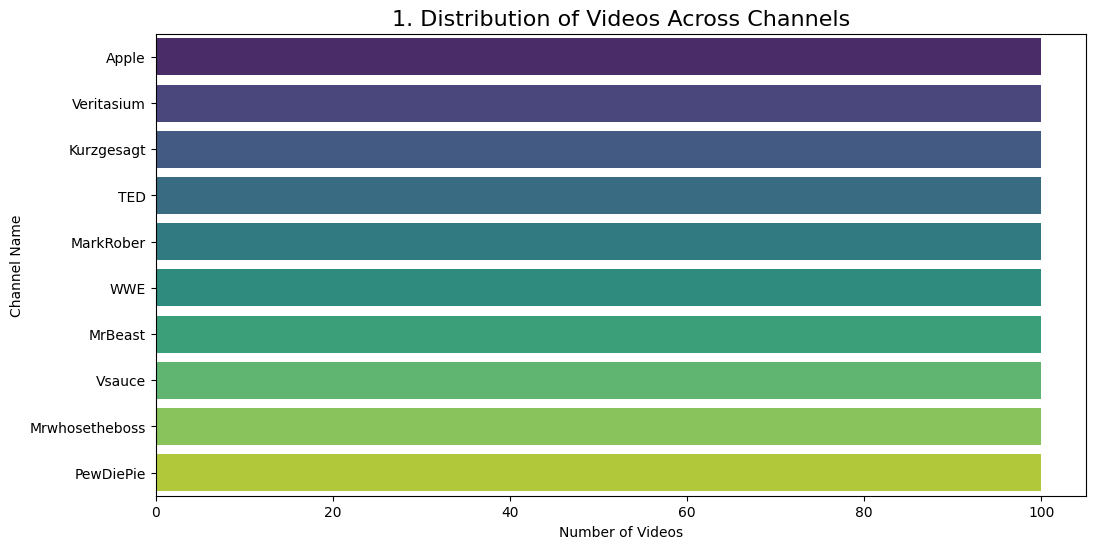

In [6]:
# Plot the number of videos per channel
plt.figure(figsize=(12, 6))
sb.countplot(data=df, y='channel', palette='viridis', order=df['channel'].value_counts().index)
plt.title('1. Distribution of Videos Across Channels', fontsize=16)
plt.xlabel('Number of Videos')
plt.ylabel('Channel Name')
plt.show()

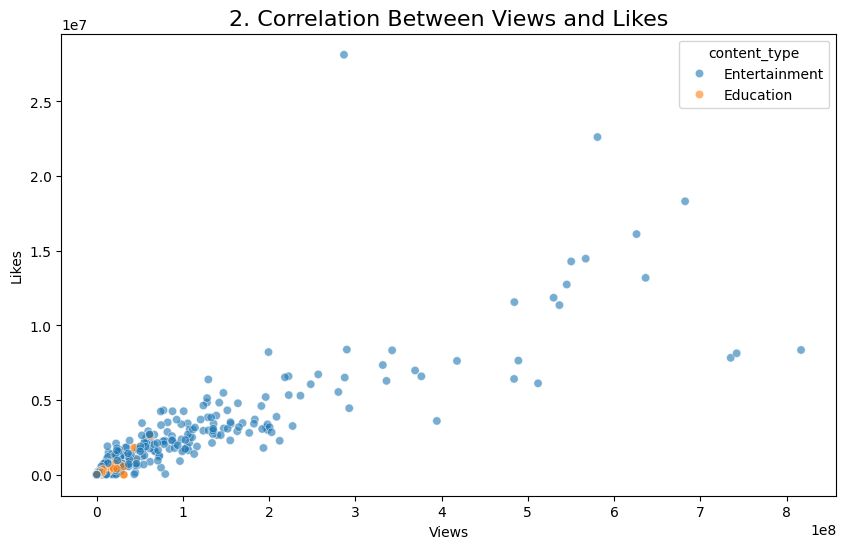

In [7]:
# Create a scatter plot to show the relationship between views and likes
plt.figure(figsize=(10, 6))
sb.scatterplot(data=df, x='views', y='likes', hue='content_type', alpha=0.6)
plt.title('2. Correlation Between Views and Likes', fontsize=16)
plt.xlabel('Views')
plt.ylabel('Likes')
plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_1652\3763795012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=top_10, x='views', y='title', palette='Blues_r')


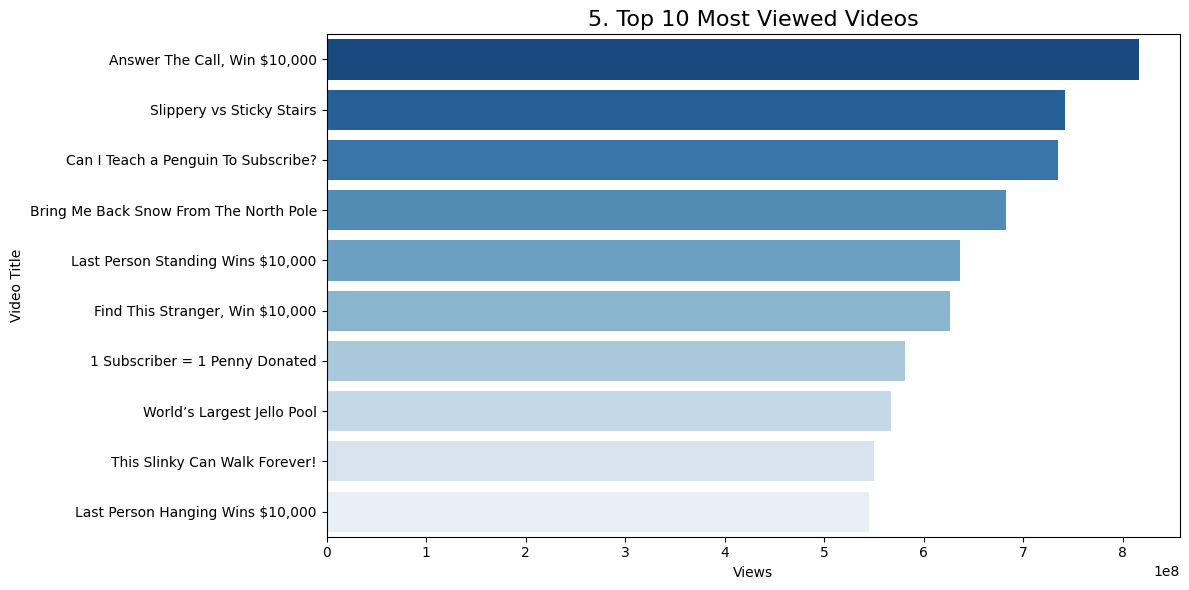

In [8]:
# Identify and plot the top 10 most viewed videos
top_10 = df.nlargest(10, 'views')
plt.figure(figsize=(12, 6))
sb.barplot(data=top_10, x='views', y='title', palette='Blues_r')
plt.title('5. Top 10 Most Viewed Videos', fontsize=16)
plt.xlabel('Views')
plt.ylabel('Video Title')
plt.tight_layout()
plt.show()

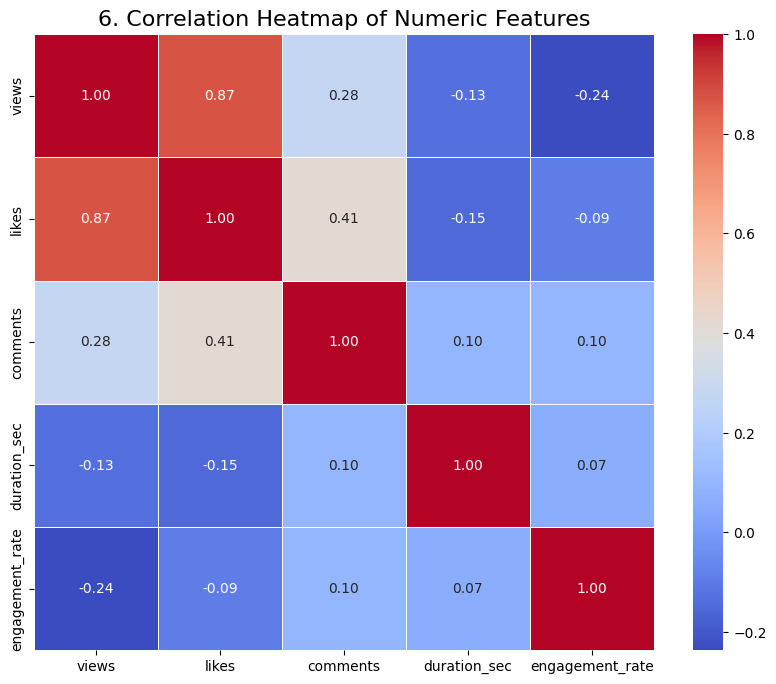

In [9]:
# Create a heatmap to see the strength of relationships between numbers
plt.figure(figsize=(10, 8))
correlation_matrix = df[['views', 'likes', 'comments', 'duration_sec', 'engagement_rate']].corr()
sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('6. Correlation Heatmap of Numeric Features', fontsize=16)
plt.show()

In [10]:
# Plot the monthly trend of total views
plt.figure(figsize=(12, 6))
sb.lineplot(data=monthly_performance, x='month_year', y='views', marker='o', color='red')
plt.title('7. Monthly Views Trend', fontsize=16)
plt.xlabel('Timeline')
plt.ylabel('Total Views')
plt.xticks(rotation=45)
plt.show()

NameError: name 'monthly_performance' is not defined

<Figure size 1200x600 with 0 Axes>

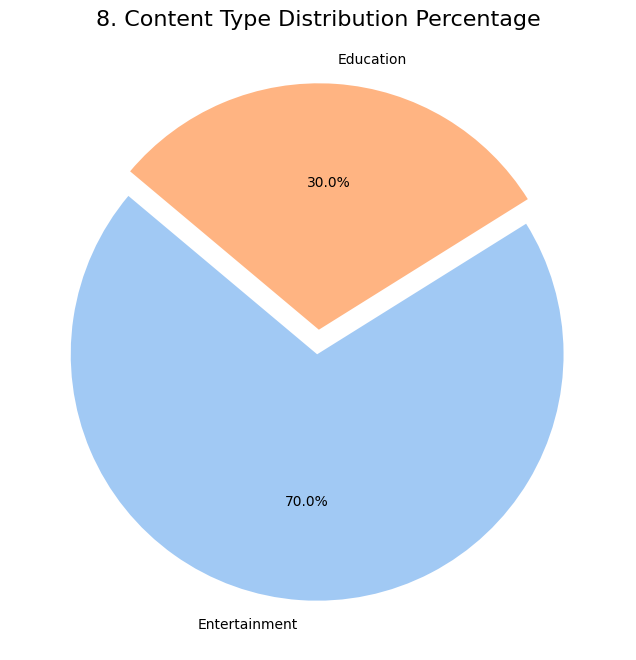

In [11]:
# Visualize the ratio of content types
plt.figure(figsize=(8, 8))
df['content_type'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=sb.color_palette('pastel'),
    startangle=140,
    explode=[0.05] * len(df['content_type'].unique()) # Adds a small gap
)
plt.title('8. Content Type Distribution Percentage', fontsize=16)
plt.ylabel('') # Hides the column name for a cleaner look
plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_1652\2294246026.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df, x='duration_group', y='views', palette='Set2')


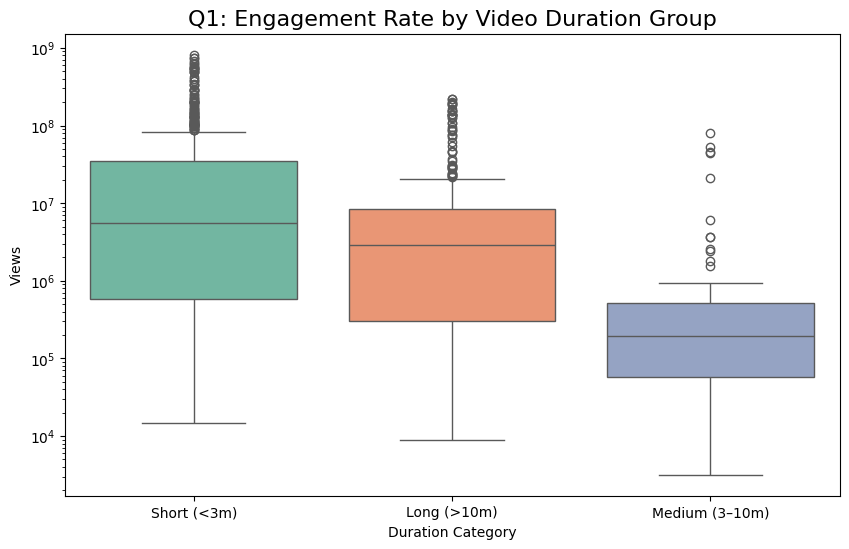

In [12]:
# Analyze views based on duration categories
plt.figure(figsize=(10, 6))
sb.boxplot(data=df, x='duration_group', y='views', palette='Set2')
plt.yscale('log') # Log scale is used because views vary from thousands to millions
plt.title('Q1: Engagement Rate by Video Duration Group', fontsize=16)
plt.xlabel('Duration Category')
plt.ylabel('Views')
plt.show()

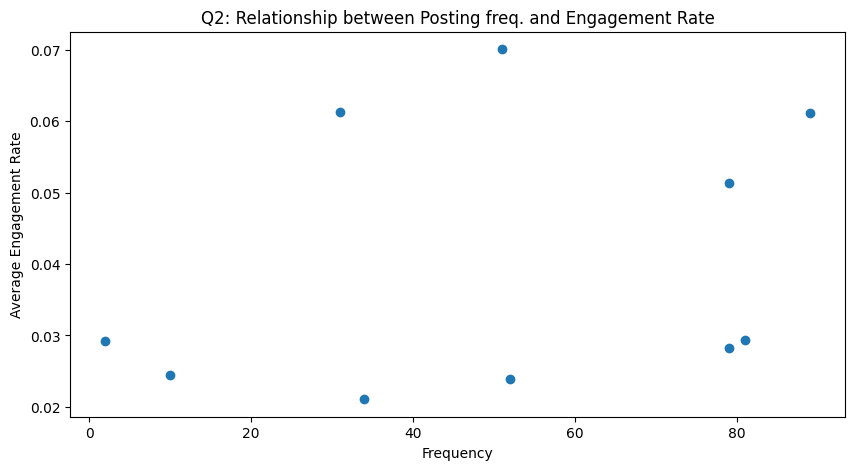

In [13]:
# Scatter plot to analyze the relationship between posting frequency and engagement rate
avg_eng = df.groupby('channel')['engagement_rate'].mean()
week_count = df.groupby('channel')['week'].nunique()
vid_count = df.groupby('channel')['title'].count()

plt.figure(figsize = [10, 5])
plt.scatter(x = week_count, y = avg_eng)

plt.title('Q2: Relationship between Posting freq. and Engagement Rate')
plt.xlabel('Frequency')
plt.ylabel('Average Engagement Rate')

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_1652\2977673655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=df, x='content_type', y='engagement_rate', palette='magma')


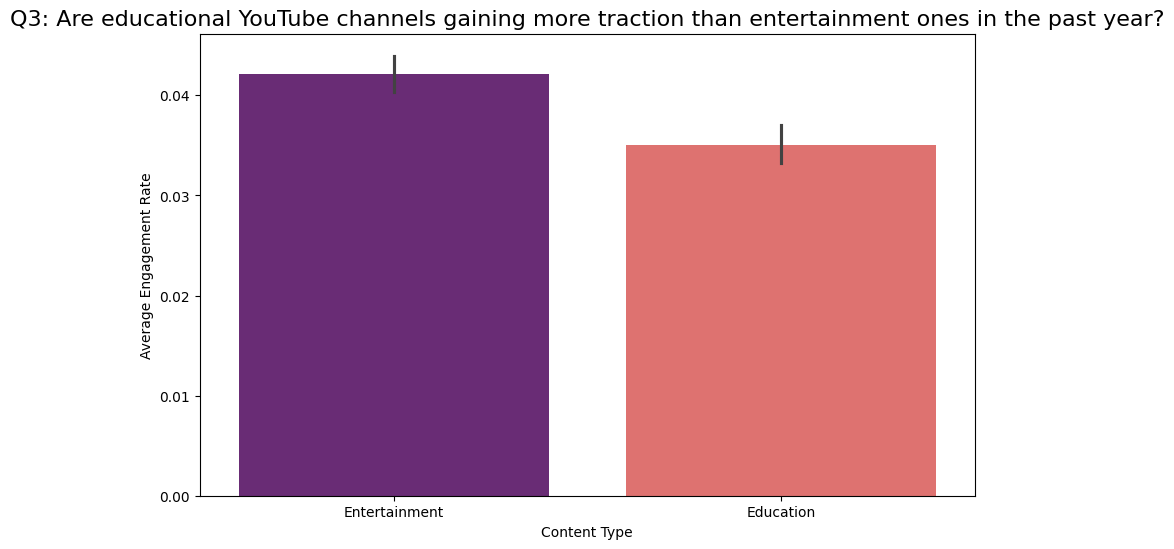

In [14]:
# Bar plot for average engagement rate by content category
plt.figure(figsize=(10, 6))
sb.barplot(data=df, x='content_type', y='engagement_rate', palette='magma')
plt.title('Q3: Are educational YouTube channels gaining more traction than entertainment ones in the past year?', fontsize=16)
plt.xlabel('Content Type')
plt.ylabel('Average Engagement Rate')
plt.show()

📊 Main Analysis

The main analysis focuses on examining the relationships between social media engagement metrics using statistical and visual techniques. Based on the insights obtained from EDA, correlation and regression-based analysis are applied to quantify the strength of relationships between variables.

The analysis investigates how views, likes, comments, and content duration influence engagement levels. By analyzing these relationships, the project identifies the most impactful features contributing to content performance.

Visualizations are used alongside statistical measures to support interpretation and ensure clarity of results. The findings from this analysis help draw conclusions about user behavior and content effectiveness on social media platforms.

The results of the analysis provide data-driven insights that can be used to improve content strategies and optimize engagement outcomes.

Slope (a): -12231.605691809698
Intercept (b): 41190025.09237849


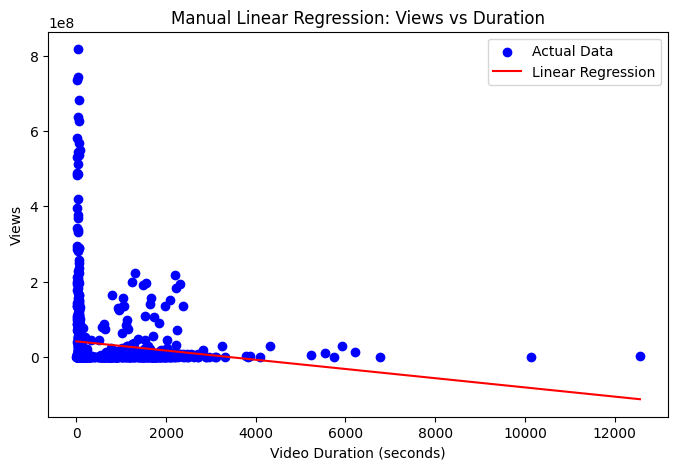

R²: 0.018045137908700437


In [15]:
# Perform manual linear regression to analyze the relationship between duration and views
X = df["duration_sec"].values
Y = df["views"].values

def manual_linear_regression(X,Y):
    # Calculate the slope and intercept for the regression line
    mean_X = np.mean(X)
    mean_Y = np.mean(Y)
    numerator = np.sum((X - mean_X)*(Y - mean_Y))
    denominator = np.sum((X - mean_X)**2)
    a = numerator / denominator
    b = mean_Y - a*mean_X
    return a, b

a, b = manual_linear_regression(X,Y)
print("Slope (a):", a)
print("Intercept (b):", b)

# Plot regression line
X_test = np.linspace(min(X), max(X), 100)
Y_pred = a*X_test + b

plt.figure(figsize=(8,5))
plt.scatter(X,Y,color='blue', label='Actual Data')
plt.plot(X_test,Y_pred,color='red', label='Linear Regression')
plt.xlabel("Video Duration (seconds)")
plt.ylabel("Views")
plt.title("Manual Linear Regression: Views vs Duration")
plt.legend()
plt.show()

# Calculate R²
Y_pred_train = a*X + b
TSS = np.sum((Y - np.mean(Y))**2)
RSS = np.sum((Y - Y_pred_train)**2)
R2 = 1 - RSS/TSS
print("R²:", R2)

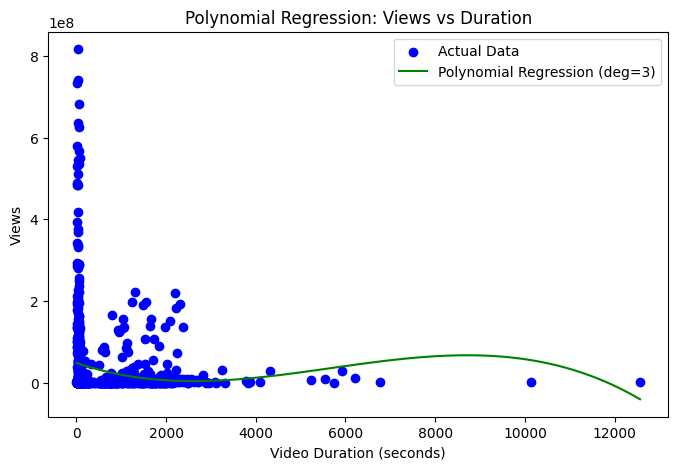

In [16]:
# Perform polynomial regression to analyze the relationship between duration and views
def polynomial_features(X, degree):
    # Generate polynomial features up to the specified degree
    X = np.array(X).reshape(-1,1)
    X_poly = np.ones((X.shape[0], degree+1))
    for d in range(1, degree+1):
        X_poly[:,d] = X[:,0] ** d
    return X_poly

degree = 3
X_poly = polynomial_features(X, degree)

# Normal Equation
W = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ Y

# Predictions
X_test_poly = polynomial_features(X_test, degree)
Y_poly_pred = X_test_poly @ W

plt.figure(figsize=(8,5))
plt.scatter(X,Y,color='blue', label='Actual Data')
plt.plot(X_test,Y_poly_pred,color='green', label=f'Polynomial Regression (deg={degree})')
plt.xlabel("Video Duration (seconds)")
plt.ylabel("Views")
plt.title("Polynomial Regression: Views vs Duration")
plt.legend()
plt.show()

In [17]:
# Perform statistical tests to compare engagement rates between short and long videos
short_videos = df[df["duration_sec"] < 180]["engagement_rate"]
long_videos = df[df["duration_sec"] >= 180]["engagement_rate"]

# Normality Test
print("Shapiro-Wilk Test (Short) p-value:", stats.shapiro(short_videos).pvalue)
print("Shapiro-Wilk Test (Long) p-value:", stats.shapiro(long_videos).pvalue)

# Variance Equality Test
print("Levene Test p-value:", stats.levene(short_videos,long_videos).pvalue)

# t-test
t_stat, t_p = stats.ttest_ind(short_videos,long_videos, equal_var=True)
print("t-test statistic:", t_stat, "p-value:", t_p)

# Mann-Whitney U Test (Non-parametric)
u_stat, u_p = stats.mannwhitneyu(short_videos,long_videos, alternative='greater')
print("Mann-Whitney U statistic:", u_stat, "p-value:", u_p)

Shapiro-Wilk Test (Short) p-value: 3.8516955068477836e-14
Shapiro-Wilk Test (Long) p-value: 8.491292846231917e-12
Levene Test p-value: 0.5041923073512933
t-test statistic: -2.5875213147137415 p-value: 0.00980729662823829
Mann-Whitney U statistic: 112193.0 p-value: 0.9968211989634381


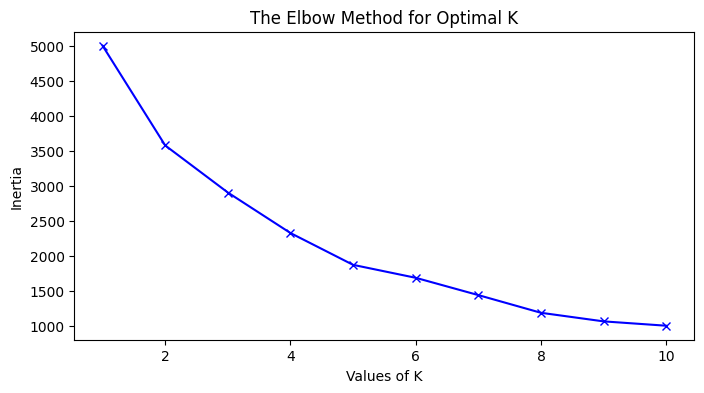

ValueError: could not convert string to float: 'Apple'

In [22]:
# Perform clustering analysis on video data
# Select features for clustering
features_to_use = ['views', 'likes', 'comments', 'engagement_rate', 'duration_sec']
data_for_clustering = df[features_to_use].copy()

# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_clustering)
#3. The Elbow Method (STRICT LAB REQUIREMENT)
# In Lab 08, you must calculate inertia for multiple K values to find the 'Elbow'
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(data_scaled)
    inertias.append(km.inertia_)

# Plotting the Elbow (As seen in CSCI322-Lab_08-Kmeans.ipynb)
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('The Elbow Method for Optimal K')
plt.show()



# 4. Perform K-Means (Using the best K identified in the elbow plot)
# Based on your lab results, let's assume K=3
kmeans = KMeans(n_clusters=4, random_state=0, max_iter=1).fit(df)
df['cluster'] = kmeans.labels_ +1 # (+1) to start from 1 not 0
df
# 5. Visualization (Using the Scatter Plot method from Lab 05 and Lab 08)
# We avoid PCA because it wasn't in the lab; we use raw features instead
plt.figure(figsize=(10, 6))
sb.scatterplot(data=df, x='views', y='engagement_rate', hue='cluster', palette='viridis')
plt.title('YouTube Video Clusters: Views vs Engagement')
plt.xlabel('Views')
plt.ylabel('Engagement Rate')
plt.legend(title='Cluster')
plt.show()



# 6. Analyze Cluster Characteristics (As done in the lab's summary step)
cluster_summary = df.groupby('cluster')[['views', 'likes', 'comments', 'engagement_rate']].mean()
print("Cluster Characteristics (Mean Values):")
print(cluster_summary)